<h1 style="text-align:center;">Interactive PCA plots of experimental CDRs</h1>

In [2]:
import os
import glob
import shutil
import pandas as pd
import numpy as np
import re

from Bio.PDB import PDBList
from pathlib import Path
from Bio.PDB import PDBParser, NeighborSearch, PDBIO, Superimposer, MMCIFParser
from Bio.SeqUtils import seq1

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
#import MDAnalysis as mda
#from MDAnalysis.coordinates.PDB import PDBWriter
from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans

std_pal = sns.color_palette("deep")

# PCA on CDRs

In [4]:
def get_chain_sequence(pdb_file, chain_id):
    """
    Get sequence based on chain id.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("tcr", pdb_file)

    seq = []
    for res in structure[0][chain_id]: 
        seq.append(seq1(res.get_resname()))

    return "".join(seq)


def extract_cdr3(sequence, min_len=7, max_len=23):
    """
    Extract CDR3 using conserved C (start) and the F/W-GxG motif (end). Ensures min_len <= CDR3 length <= max_len.
    """
    # find all conserved C positions
    c_positions = [m.start() for m in re.finditer("C", sequence)]
    if not c_positions:
        return None

    # try Cs from last to first (most likely real CDR3 start)
    for c_pos in reversed(c_positions):
        subseq = sequence[c_pos:]

        # find all FGXG / WGXG motifs after this C
        matches = list(re.finditer(r"([FW])G.G", subseq))
        if not matches:
            continue

        # check motifs from LAST to FIRST
        for match in reversed(matches):
            end = c_pos + match.start(1) + 1
            cdr3 = sequence[c_pos:end]

            L = len(cdr3)
            if min_len <= L <= max_len:
                return cdr3

    return None

def extract_cdr_coords(pdb_path, cdr_dict, chain_map={"TRA":"A","TRB":"B"}):
    """
    Extract coordinates of CDRs based on the respective sequences.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("pdb", pdb_path)
    
    cdr_coords = {}
    
    for chain_label, chain_id in chain_map.items():
        chain_obj = structure[0][chain_id]
        
        # Get all residues with C-alpha
        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]
        
        # Convert 3-letter PDB codes to 1-letter
        seq = "".join([seq1(res.get_resname()) for res in residues])
        
        cdr_coords[chain_label] = {}
        
        # loop over CDR1/2/3
        for i, cdr_key in enumerate([f"CDR1{chain_label[-1]}", f"CDR2{chain_label[-1]}", f"CDR3{chain_label[-1]}"], 1):
            cdr_seq = cdr_dict[cdr_key].upper()
            L = len(cdr_seq)
            
            # find CDR sequence in the chain sequence
            start_idx = seq.find(cdr_seq)
            if start_idx == -1:
                print(f"Warning: CDR {cdr_key} sequence not found in chain {chain_id} of {pdb_path}")
                return None
            
            end_idx = start_idx + L
            
            # extract C-alpha coordinates
            coords = np.array([res["CA"].get_coord() for res in residues[start_idx:end_idx]])
            cdr_coords[chain_label][f"cdr{i}"] = coords
            
    return cdr_coords


def build_coord_matrix(cdr_coord_dict, min_cdr_lengths):
    """
    Build coordinate matrix with fixed-length CDRs.
    """
    coord_matrix = []
    for tcr, chains in cdr_coord_dict.items():
        vec = []
        for chain, cdrs in chains.items():
            for cdr_name in ["cdr1","cdr2"]:
                coords = cdrs[cdr_name]
                L = min_cdr_lengths[chain][cdr_name]
                # first 2 + last L-2
                selected = np.vstack([coords[:2], coords[-(L-2):]])
                vec.extend(selected.flatten())
            # CDR3: first 5 + last L-5
            coords = cdrs["cdr3"]
            L = min_cdr_lengths[chain]["cdr3"]
            selected = np.vstack([coords[:5], coords[-(L-5):]])
            vec.extend(selected.flatten())
        coord_matrix.append(vec)
    
    return np.array(coord_matrix)


In [ ]:
df = pd.read_csv('tcr_pdbs_chains_david_mhci_fixed.csv', sep=';')
indir = '../260202_YF-modes/pdbs_mhci_align'

pdbs = glob.glob(f'{indir}/*.pdb')
pdbs.sort()

pdbs = [p for p in pdbs if os.path.basename(p).split('.')[0] in df['PDB'].values]

cdr_coord_dict = {}
pdb_ids = []
for pdb_file in pdbs:
    pdb_id = os.path.basename(pdb_file).split('.')[0]
    
    # exctract CDR coordinates
    row = df[df["PDB"] == pdb_id]
    cdr_dict = {cdr: str(row[cdr].values[0]).upper() for cdr in ["CDR1A","CDR2A","CDR3A_fix","CDR1B","CDR2B","CDR3B_fix"]}
    cdr_dict['CDR3A'] = cdr_dict.pop('CDR3A_fix') # rename dict keys
    cdr_dict['CDR3B'] = cdr_dict.pop('CDR3B_fix')

    cdr_coords = extract_cdr_coords(pdb_file, cdr_dict, chain_map={"TRA":"D","TRB":"E"})
    cdr_coord_dict[pdb_id] = cdr_coords
    pdb_ids.append(pdb_id)

# minimal CDR lengths
min_cdr_lengths = {}
for chain_label in ["TRA","TRB"]:
    min_cdr_lengths[chain_label] = {}
    for cdr_name in ["cdr1","cdr2","cdr3"]:
        min_len = min(cdr_coord_dict[pdb_id][chain_label][cdr_name].shape[0] 
                    for pdb_id in cdr_coord_dict)
        min_cdr_lengths[chain_label][cdr_name] = min_len
print(min_cdr_lengths)

# build coordinate matrix and perform pca
coord_matrix = build_coord_matrix(cdr_coord_dict, min_cdr_lengths)
coord_matrix = pd.DataFrame(coord_matrix)
coord_matrix.insert(0, 'PDB', pdb_ids)
coord_matrix.to_pickle('coord_matrix_exp.pkl')

with open("min_cdr_lengths_exp.pkl", "wb") as f:
    pickle.dump(min_cdr_lengths, f)

{'TRA': {'cdr1': 5, 'cdr2': 4, 'cdr3': 10}, 'TRB': {'cdr1': 5, 'cdr2': 5, 'cdr3': 11}}


In [30]:
anno = pd.read_csv('tcr_pdbs_chains_david_mhci_fixed.csv', sep=';')[['PDB', 'epitope', 'CDR1A', 'CDR2A', 'CDR3A_fix', 'CDR1B', 'CDR2B', 'CDR3B_fix', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ']]
anno = anno.rename(columns={'epitope':'peptide', 'CDR3A_fix':'CDR3A', 'CDR3B_fix':'CDR3B'})

df = pd.read_pickle('coord_matrix_exp.pkl')

with open("min_cdr_lengths_exp.pkl", "rb") as f:
    min_cdr_lengths = pickle.load(f)

for chain, cdr_dict in min_cdr_lengths.items():
    col_offset = 0  # track position in the coordinate columns
    for cdr, length in cdr_dict.items():
        tmp = df.copy()
        pdb_ids = tmp['PDB'].values

        # drop first column (PDB)
        tmp = tmp.drop(columns=tmp.columns[0])
        
        # access the correct coordinates for this CDR (3 coords per residue)
        n_cols = 3 * length
        cdr_coords = tmp.iloc[:, col_offset:col_offset + n_cols]
        
        col_offset += n_cols

        # perform pca
        pca = PCA(n_components=2)
        pcs = pca.fit_transform(cdr_coords)

        df_pca = pd.DataFrame()
        df_pca['PC1'] = pcs[:,0]
        df_pca['PC2'] = pcs[:,1]
        df_pca['PDB'] = np.array(pdb_ids)

        df_merged = pd.merge(df_pca, anno, on='PDB')
        df_merged.to_pickle(f'pca_exp_{chain}_{cdr}.pkl')

In [32]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pickle

# ── load min_cdr_lengths (adjust filename if needed) ──────────────────────────
with open("min_cdr_lengths_exp.pkl", "rb") as f:
    min_cdr_lengths = pickle.load(f)

chains = list(min_cdr_lengths.keys())   # ["TRA", "TRB"]
cdrs   = list(min_cdr_lengths[chains[0]].keys())  # ["cdr1", "cdr2", "cdr3"]

# ── build per-chain color maps ─────────────────────────────────────────────────
gene_col = {"TRA": "TRAV", "TRB": "TRBV"}
all_genes = {c: set() for c in chains}

for chain in chains:
    for cdr in cdrs:
        df_tmp = pd.read_pickle(f"pca_exp_{chain}_{cdr}.pkl")
        all_genes[chain].update(df_tmp[gene_col[chain]].dropna().unique())

palette = px.colors.qualitative.Plotly + px.colors.qualitative.Dark24
color_map = {
    chain: {g: palette[i % len(palette)] for i, g in enumerate(sorted(all_genes[chain]))}
    for chain in chains
}

# ── build subplots ─────────────────────────────────────────────────────────────
subplot_titles = [f"{chain} {cdr.upper()}" for chain in chains for cdr in cdrs]
fig = make_subplots(rows=2, cols=3, subplot_titles=subplot_titles,
                    horizontal_spacing=0.08, vertical_spacing=0.12)

seen_legend = set()

hover_cols = ["PDB", "peptide", "TRAV", "TRAJ", "TRBV", "TRBJ", "CDR3A", "CDR3B"]

for row_i, chain in enumerate(chains, 1):
    for col_i, cdr in enumerate(cdrs, 1):
        df_pca = pd.read_pickle(f"pca_exp_{chain}_{cdr}.pkl")
        gcol = gene_col[chain]

        for gene, grp in df_pca.groupby(gcol, sort=True):
            legend_key = f"{chain}|{gene}"
            show = legend_key not in seen_legend
            if show:
                seen_legend.add(legend_key)

            # fill missing hover columns with "n/a" so customdata is always 8-wide
            cdata = grp.reindex(columns=hover_cols).fillna("n/a").values

            fig.add_trace(
                go.Scatter(
                    x=grp["PC1"], y=grp["PC2"],
                    mode="markers",
                    marker=dict(
                        color=color_map[chain].get(gene, "#aaaaaa"),
                        size=8, symbol="x", line=dict(width=1.5)
                    ),
                    name=str(gene),
                    legendgroup=f"{chain}|{gene}",
                    legendgrouptitle_text=chain if (show and col_i == 1 and gene == sorted(all_genes[chain])[0]) else None,
                    showlegend=show,
                    customdata=cdata,
                    hovertemplate=(
                        "<b>%{customdata[0]}</b><br>"
                        "Peptide: %{customdata[1]}<br>"
                        "TRAV: %{customdata[2]} &nbsp; TRAJ: %{customdata[3]}<br>"
                        "TRBV: %{customdata[4]} &nbsp; TRBJ: %{customdata[5]}<br>"
                        "CDR3α: %{customdata[6]}<br>"
                        "CDR3β: %{customdata[7]}"
                        "<extra></extra>"
                    ),
                ),
                row=row_i, col=col_i,
            )

fig.update_layout(
    height=650, width=1100,
    title_text="PCA of experimental CDR structures",
    legend=dict(groupclick="toggleitem"),
)
fig.update_xaxes(title_text="PC1")
fig.update_yaxes(title_text="PC2")

fig.write_html("pca_exp_interactive.html")

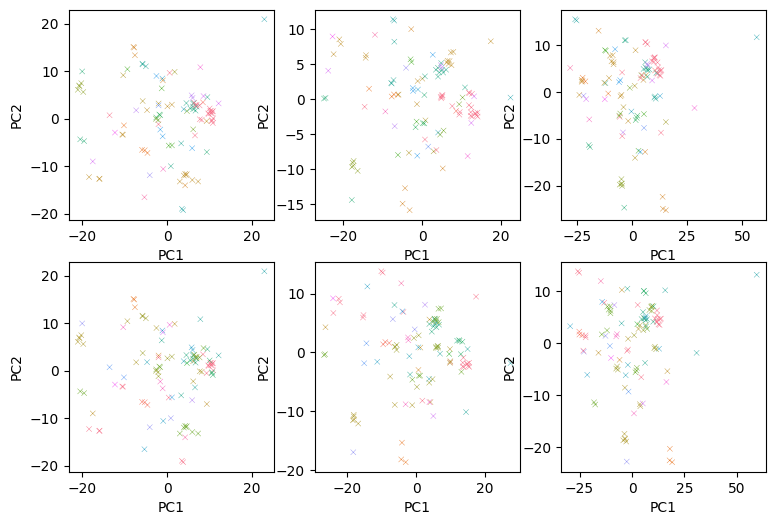

In [22]:
with open("min_cdr_lengths_exp.pkl", "rb") as f:
    min_cdr_lengths = pickle.load(f)

fig, axes = plt.subplots(2,3,figsize=(9,6))

for cnt1, (chain, cdr_dict) in enumerate(min_cdr_lengths.items()):
    for cnt2, (cdr, length) in enumerate(cdr_dict.items()):
        ax = axes[cnt1][cnt2]

        df = pd.read_pickle(f'pca_exp_{chain}_{cdr}.pkl')
        sns.scatterplot(df, x='PC1', y='PC2', ax=ax, marker='x', s=15, hue=f'{chain}V', legend=False)
